## PV shadow analysis for Bank 2 (West, 260°).

Two separate shadow matrices (North 6+2, South 4+2) are loaded and
analysed independently. Each sub-array gets its own SiteConfig with
the correct nominal power share. The final power output is the sum
of both sub-arrays, which is compared against the Bank 2 inverter
channel (MPP2).

Bank 2 specifications:
  - Orientation: 260° (West)
  - Inclination: 20°
  - 14 panels total, 4620 W nominal
  - North (6+2 = 8 panels): 8/14 × 4620 = 2640 W
  - South (4+2 = 6 panels): 6/14 × 4620 = 1980 W

Roof geometry (annotated aerial image):
  BANK 1 — SE-facing (main_analysis.py)
    Azimuth: 170°   Tilt: 12°   Panels: 12   Nominal: 3 960 W
    Inverter channel: MPP1
    Panels: 1-1…1-12

  BANK 2 — West-facing (this script)
    Azimuth: 260°   Tilt: 20°   Panels: 14   Nominal: 4 620 W
    Inverter channel: MPP2

    Part 1 — North sub-array (8 panels)
      Layout: (6, 2) left-aligned
      Anchor corner: (532882.93, 6983518.73) — panel 2-1-1 at (532884.50, 6983518.50)
      Row 0: 2-1-1  2-1-2  2-1-3  2-1-4  2-1-5  2-1-6
      Row 1: 2-1-7  2-1-8

    Part 2 — South sub-array (6 panels)
      Layout: (4, 2) right-aligned
      Anchor corner: (532888.63, 6983503.79) — panel 2-2-1 at (532889.50, 6983507.50)
      Row 0: 2-2-1  2-2-2  2-2-3  2-2-4
      Row 1: 2-2-5  2-2-6

Two separate shadow matrices are loaded and analysed independently.
Each sub-array gets its own SiteConfig with the correct nominal power
share. The final power output is the sum of both sub-arrays, compared
against the Bank 2 inverter channel (MPP2).

In [1]:
# %% --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MANUSCRIPT_FIG_DIR = Path("/Users/hdong/Projects/VoxSolaris_Article/figs")
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
})


from pv_analysis_b2 import (
    SiteConfig,
    find_clear_days,
    load_and_smooth_shadow_matrix,
    load_extra_data_csv,
    load_inverter_data,
    pv_analysis,
    compute_metrics,
    print_performance_summary,
    plot_real_vs_predicted_scatter,
    save_all_day_plots,
)

from shadow_matrix_simulation_b2 import create_shadow_matrices

try:
    from visual_utils import plot_shadow_matrix_with_sunpaths, plot_shadow_polar_b2
except ImportError:
    plot_shadow_matrix_with_sunpaths = None
    plot_shadow_polar_b2 = None

import tqdm

In [2]:
# %% --- Configuration: Bank 2 (West, 260°, 14 panels, MPP2) ---
# Panel counts
N_NORTH = 8   # Part 1: panels 2-1-1 … 2-1-8
N_SOUTH = 6   # Part 2: panels 2-2-1 … 2-2-6
N_TOTAL = 14
NOMINAL_TOTAL_W = 4620.0

cfg_north = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=20.0,
    azimuth_deg=260.0,
    nominal_power_kw=NOMINAL_TOTAL_W * N_NORTH / N_TOTAL / 1000,  # 2.64 kW
    system_efficiency=0.85,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,
    window_size=(2, 2),
    interval="5min",
    interval_minutes=5.0,
    forecast_shift_minutes=-30,
)

cfg_south = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=20.0,
    azimuth_deg=260.0,
    nominal_power_kw=NOMINAL_TOTAL_W * N_SOUTH / N_TOTAL / 1000,  # 1.98 kW
    system_efficiency=0.85,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,
    window_size=(2, 2),
    interval="5min",
    interval_minutes=5.0,
    forecast_shift_minutes=-30,
)

# Combined cfg for metrics display / full-bank scatter plots
cfg_combined = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=20.0,
    azimuth_deg=260.0,
    nominal_power_kw=NOMINAL_TOTAL_W / 1000,  # 4.62 kW
    system_efficiency=0.85,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,
    window_size=(2, 2),
    interval="5min",
    interval_minutes=5.0,
    forecast_shift_minutes=-30,
)


# --- File Paths ---
RAD_FILE       = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_rad.csv"
TEMP_WIND_FILE = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_temp_wind.csv"
CLEAR_MINUTES  = "data/Clear_sky_minutes_kuopio_RH16.txt"
PV_EXCEL       = "data/pvdata/pv_21.xlsx"

LIDAR_FILE     = "output/reclassified_final_v5.laz"
SHADOW_DIR     = "results/shadow_matrix_results_W_pro"
SHADOW_NORTH   = f"{SHADOW_DIR}/shadow_attenuation_matrix_conecasting_W_north_v3.csv"
SHADOW_SOUTH   = f"{SHADOW_DIR}/shadow_attenuation_matrix_conecasting_W_south_v3.csv"
EXTRA_DATA_DIR = "output"

In [3]:
import pvlib

def replace_dni_with_computed(df_extra, latitude, longitude):
    """
    Replace CAMS DNI with DNI computed from GHI, DHI, and solar zenith.
    Uses pvlib closure: DNI = (GHI - DHI) / cos(zenith)
    """
    solpos = pvlib.solarposition.get_solarposition(
        df_extra.index, latitude, longitude
    )
    zenith = solpos["apparent_zenith"]

    dni_computed = pvlib.irradiance.dni(
        ghi=df_extra["ghi"],
        dhi=df_extra["dhi"],
        zenith=zenith,
        # clearsky_dni=None,       # no clearsky limit
        # clearsky_tolerance=1.1,
    )

    df_extra["dni_cams"] = df_extra["dni"].copy()  # keep original
    df_extra["dni"] = dni_computed.clip(lower=0)

    return df_extra

In [4]:
# %% --- 3. Generate Shadow Matrices (run once) ---
# Uncomment to generate:
_ = create_shadow_matrices(
    lidar_file_path=LIDAR_FILE,
    voxel_size=2.0,
    output_dir=SHADOW_DIR,
    skip_dist=1.0,
    offset_from_roof=-1.5,
    file_name_suffix="v3"
)

Loading LiDAR data from output/reclassified_final_v5.laz...
  2,327,728 points after filtering.
  Voxel grid: 250×250×29 = 1,812,500 voxels

  --- Sub-array: North (6, 2) — left-aligned ---
    Panels: 2-1-1…2-1-6 (row 0), 2-1-7…2-1-8 (row 1)
    Roof: 190 pts, max_z=97.13m, offset=-1.5m → panel_z=95.63m
    8 panel points

  --- Sub-array: South (4, 2) — right-aligned ---
    Panels: 2-2-1…2-2-4 (row 0), 2-2-5…2-2-6 (row 1)
    Roof: 3 pts, max_z=96.87m, offset=-1.5m → panel_z=95.37m
    6 panel points

  Self-occlusion skip distance: 1.0m (voxel_size=2.0m)

--- JIT warm-up (first trace) ---


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



--- Sweep: North (6+2) (8 panels) ---
  Elevation   9.0° done  (3,600/32,760 = 11.0%)  [1s elapsed]
  Elevation  19.0° done  (7,200/32,760 = 22.0%)  [1s elapsed]
  Elevation  29.0° done  (10,800/32,760 = 33.0%)  [2s elapsed]
  Elevation  39.0° done  (14,400/32,760 = 44.0%)  [2s elapsed]
  Elevation  49.0° done  (18,000/32,760 = 54.9%)  [3s elapsed]
  Elevation  59.0° done  (21,600/32,760 = 65.9%)  [3s elapsed]
  Elevation  69.0° done  (25,200/32,760 = 76.9%)  [4s elapsed]
  Elevation  79.0° done  (28,800/32,760 = 87.9%)  [5s elapsed]
  Elevation  89.0° done  (32,400/32,760 = 98.9%)  [5s elapsed]
  Elevation  90.0° done  (32,760/32,760 = 100.0%)  [5s elapsed]
  North (6+2) completed in 5.3s

--- Sweep: South (4+2) (6 panels) ---
  Elevation   9.0° done  (3,600/32,760 = 11.0%)  [1s elapsed]
  Elevation  19.0° done  (7,200/32,760 = 22.0%)  [1s elapsed]
  Elevation  29.0° done  (10,800/32,760 = 33.0%)  [2s elapsed]
  Elevation  39.0° done  (14,400/32,760 = 44.0%)  [3s elapsed]
  Elevation

In [5]:
# %% --- 4. Load Shadow Matrices ---
shadow_north = load_and_smooth_shadow_matrix(SHADOW_NORTH, window_size=cfg_north.window_size)
shadow_south = load_and_smooth_shadow_matrix(SHADOW_SOUTH, window_size=cfg_south.window_size)
print(f"Shadow matrices loaded — North: {shadow_north.shape}, South: {shadow_south.shape}")

Shadow matrices loaded — North: (91, 361), South: (91, 361)


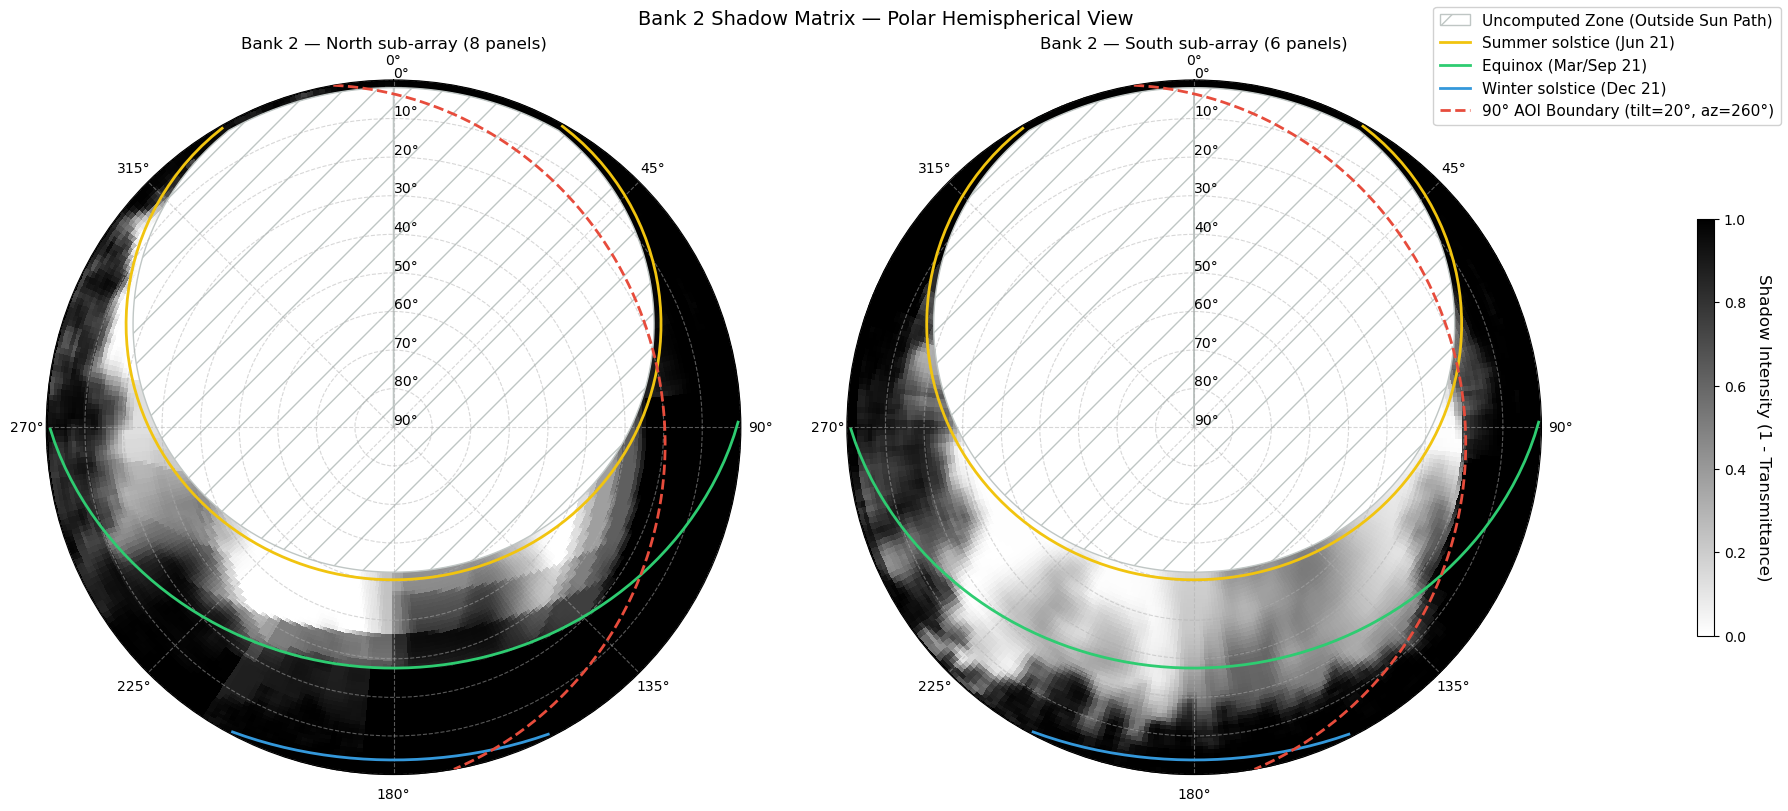

In [6]:
# %% --- 5. Visualise Shadow Matrices ---

if plot_shadow_polar_b2 is not None:
    plot_shadow_polar_b2(
        SHADOW_NORTH,
        SHADOW_SOUTH,
        save_path=str(MANUSCRIPT_FIG_DIR / "SAM_bank2.png"),
        show=True,
        dpi=300,
    )


In [7]:
# %% --- 6. Load Inverter Data (Bank 2 = MPP2) ---
pv_df = load_inverter_data(
    PV_EXCEL,
    expected_interval_min=cfg_combined.interval_minutes,
    energy_column="MPP2",
)
print(f"Loaded {len(pv_df)} inverter records (Bank 2 / MPP2).")

  Energy column: 'Energia MPP2 | Symo 8.2-3-M (1)' (index 3)
Inverter data: 102,263 records, 102235/102262 normal intervals, 27 gaps
  Largest gaps: [965. 925. 905. 875. 825.] min
Loaded 102263 inverter records (Bank 2 / MPP2).


In [8]:
# %% --- 7. Combined PV Analysis for a Single Day ---
def pv_analysis_bank2(
    target_date, shadow_north, shadow_south,
    excel_df, df_extra, plot=True, save_path=None,
):
    """
    Run PV analysis for Bank 2 by analysing North and South sub-arrays
    separately, then summing their outputs.

    Returns
    -------
    day_data : DataFrame with real power (full Bank 2)
    fb_combined : DataFrame with base forecast (no shadows)
    fw_combined : DataFrame with shadow-corrected forecast
    """
    # North sub-array
    day_n, fb_n, fw_n = pv_analysis(
        target_date, shadow_north, excel_df, df_extra,
        cfg=cfg_north, plot=False,
    )
    # South sub-array
    day_s, fb_s, fw_s = pv_analysis(
        target_date, shadow_south, excel_df, df_extra,
        cfg=cfg_south, plot=False,
    )

    # Real power is the full Bank 2 measurement (not split)
    day_data = day_n.copy()  # same inverter data for both

    # Combined forecast = sum of sub-arrays
    fb_combined = fb_n.copy()
    fb_combined["output"] = fb_n["output"] + fb_s["output"]

    fw_combined = fw_n.copy()
    fw_combined["output_shaded"] = fw_n["output_shaded"] + fw_s["output_shaded"]

    if plot:
        import matplotlib.dates as mdates
        fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

        full_idx = day_data.index

        # --- Top: Combined ---
        ax = axes[0]
        ax.plot(full_idx, day_data["Power_W"],
                label="Real Power (Bank 2)", color="#2ecc71", lw=1.5)
        ax.plot(full_idx, fb_combined["output"],
                label="Base Forecast (N+S)", color="#3498db", ls="--", lw=1.6)
        ax.plot(full_idx, fw_combined["output_shaded"],
                label="Shadow-Corrected (N+S)", color="#e67e22", lw=1.6)
        ax.set_title(f"Bank 2 Combined — {target_date}", fontsize=13)
        ax.set_ylabel("Power (W)", fontsize=12)
        ax.legend(loc="upper right", fontsize=10)
        ax.grid(True, alpha=0.3)

        # --- Middle: North sub-array ---
        ax = axes[1]
        ax.plot(full_idx, fb_n["output"],
                label="Base (North 6+2)", color="#3498db", ls="--")
        ax.plot(full_idx, fw_n["output_shaded"],
                label="Shaded (North 6+2)", color="#e67e22")
        ax.set_title("North Sub-array (6+2, 8 panels)", fontsize=12)
        ax.set_ylabel("Power (W)", fontsize=12)
        ax.legend(loc="upper right", fontsize=10)
        ax.grid(True, alpha=0.3)

        # --- Bottom: South sub-array ---
        ax = axes[2]
        ax.plot(full_idx, fb_s["output"],
                label="Base (South 4+2)", color="#3498db", ls="--")
        ax.plot(full_idx, fw_s["output_shaded"],
                label="Shaded (South 4+2)", color="#e67e22")
        ax.set_title("South Sub-array (4+2, 6 panels)", fontsize=12)
        ax.set_ylabel("Power (W)", fontsize=12)
        ax.set_xlabel("Time (Local)", fontsize=12)
        ax.legend(loc="upper right", fontsize=10)
        ax.grid(True, alpha=0.3)

        for a in axes:
            a.xaxis.set_major_locator(mdates.HourLocator(interval=1))
            a.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            a.set_xlim(full_idx[0], full_idx[-1])
            a.tick_params(axis="both", labelsize=10)

        plt.tight_layout()
        plt.show()

    return day_data, fb_combined, fw_combined

In [9]:
# %% --- 10. Multi-Day Batch Evaluation ---
# def _load_cached_extra(date_obj):
#     try:
#         return load_extra_data_csv(
#             f"{EXTRA_DATA_DIR}/extra_data_{date_obj}.csv", cfg=cfg_combined
#         )
#     except FileNotFoundError:
#         print(f"  Warning: No extra data for {date_obj}, skipping.")
#         return None

# %% --- Build extra_data from FMI CSVs ---
from build_extra_data import make_extra_data_loader

RAD_CSV = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_rad.csv"
TW_CSV  = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_temp_wind.csv"
LAT, LON = 62.8924, 27.6353

extra_loader = make_extra_data_loader(
    rad_csv=RAD_CSV, temp_wind_csv=TW_CSV,
    latitude=LAT, longitude=LON,
)

# # %% --- 2. Load Extra Data for First Clear Day (test) ---
# second_day = clear_days["Date"].iloc[1]
# extra_data_df = extra_loader(second_day)
# print(extra_data_df.head())

# # %% --- 10. Multi-Day Batch Evaluation ---
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# daily_stats = []
# all_real = []
# all_pred_shaded = []
# all_pred_base = []

# for date_obj in tqdm.tqdm(clear_days_fraction["Date"].tolist(), desc="Evaluating Bank 2"):
#     df_extra = extra_loader(date_obj)
#     if df_extra is None or df_extra.empty:
#         continue

#     dd, fb, fw = pv_analysis_bank2(
#         date_obj, shadow_north, shadow_south,
#         pv_df, df_extra, plot=False,
#     )
#     metrics = compute_metrics(dd, fb, fw, cfg_combined.interval_minutes)

#     all_real.extend(dd["Power_W"].fillna(0.0).values)
#     all_pred_shaded.extend(fw["output_shaded"].fillna(0.0).values)
#     all_pred_base.extend(fb["output"].fillna(0.0).values)

#     daily_stats.append({
#         "Date": (date_obj.strftime("%Y-%m-%d")
#                  if hasattr(date_obj, "strftime") else str(date_obj)),
#         **metrics,
#     })

# results_df = pd.DataFrame(daily_stats)

# if not results_df.empty:
#     plot_real_vs_predicted_scatter(
#         all_real, all_pred_base,
#         title="Real vs. FMI Base Forecast — Bank 2 (All Clear Days)",
#         ylabel="FMI Forecast — No Shadows (W)",
#         save_path=str(MANUSCRIPT_FIG_DIR / "b2_clearsky_scatter_base.png"),
#         )
#     plot_real_vs_predicted_scatter(
#         all_real, all_pred_shaded,
#         title="Real vs. Shadow-Corrected — Bank 2 (All Clear Days)",
#         ylabel="Shadow-Corrected Forecast (W)",
#         save_path=str(MANUSCRIPT_FIG_DIR / "b2_clearsky_scatter_corr.png"),
#         )

# print_performance_summary(results_df, real_arr=all_real, base_arr=all_pred_base, shaded_arr=all_pred_shaded)

Evaluating 153 days: 2021-05-01 → 2021-09-30


All days: 100%|██████████| 153/153 [00:04<00:00, 31.27it/s]


Per-day results saved to: all_days_metrics_bank2.csv

  OVERALL METRICS — 2021-05-01 to 2021-09-30
  153 days evaluated, 0 skipped, 27396 daytime samples

  Metric                   Baseline  Shadow-Corr  Improvement
  --------------------------------------------------------
  RMSE (W)                    635.1        470.6        25.9%
  MAE (W)                     412.1        286.8        30.4%
  MBE (W)                     259.7        -46.8       closer
  R²                          0.298        0.614       +0.317

  Energy (kWh)             Real       Base  Corrected
  ------------------------------------------------
  Total                  1737.5     2336.9     1634.4
  Error                             +34.5%      -5.9%

  Per-day averages (mean of 153 daily metrics):
  RMSE      Base: 584.1 ± 230.3   Corr: 426.6 ± 178.2
  MAE       Base: 402.6 ± 168.3   Corr: 279.3 ± 106.7
  MBE       Base: 253.3 ± 173.9   Corr: -51.1 ± 97.5
  R²        Base: -0.213 ± 1.130   Corr: 0.385 ± 0.3

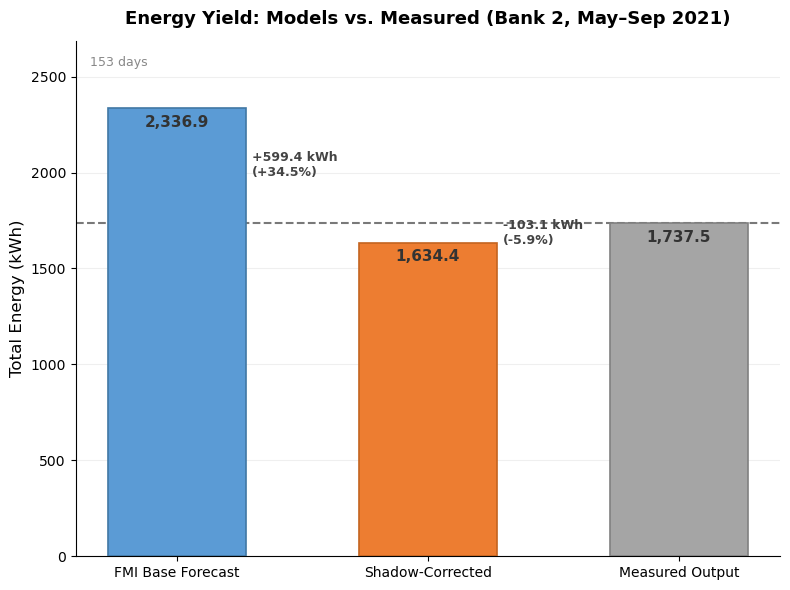

Saved: /Users/hdong/Projects/VoxSolaris_Article/figs/b2_fullperiod_rmse.png


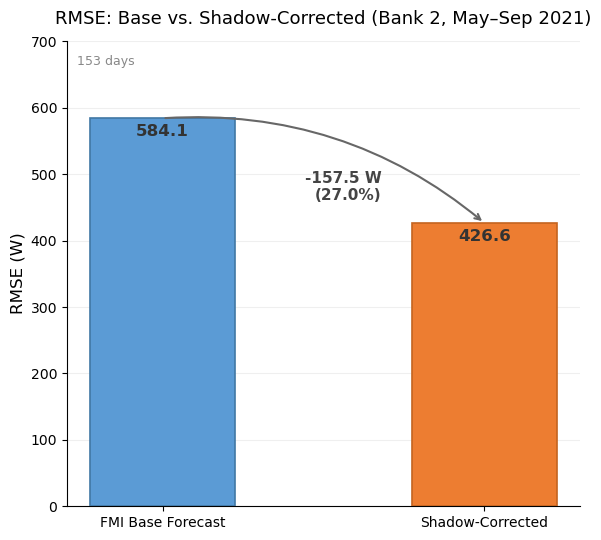

In [10]:
# %% --- 13. Evaluate ALL days May–September (Bank 2) ---
from evaluate_all_days import evaluate_all_days, plot_energy_bar_chart, _plot_metric_comparison

def _bank2_pv_analysis_wrapper(date_obj, shadow_matrix, excel_df, df_extra, cfg, plot=False):
    """Wrapper so evaluate_all_days can call Bank 2's dual-matrix analysis."""
    return pv_analysis_bank2(
        date_obj, shadow_north, shadow_south,
        excel_df, df_extra, plot=False,
    )

# Monkey-patch pv_analysis in evaluate_all_days for Bank 2
import evaluate_all_days as _ead
_original_pv = None
try:
    import pv_analysis_b2 as _pva
    _original_pv = _pva.pv_analysis
    _pva.pv_analysis = _bank2_pv_analysis_wrapper

    all_results_b2, all_real_b2, all_base_b2, all_shad_b2 = evaluate_all_days(
        start_date="2021-05-01",
        end_date="2021-09-30",
        shadow_matrix=shadow_north,  # placeholder, wrapper ignores it
        excel_df=pv_df,
        extra_data_loader=extra_loader,
        cfg=cfg_combined,
        output_csv="all_days_metrics_bank2.csv",
    )

    plot_energy_bar_chart(
        all_results_b2,
        title_suffix="Bank 2, May–Sep 2021",
        save_path=str(MANUSCRIPT_FIG_DIR / "b2_fullperiod_energy.png"),
    )
    _plot_metric_comparison(
        all_results_b2["RMSE_Base"].mean(),
        all_results_b2["RMSE_Shaded"].mean(),
        "RMSE",
        "W",
        n_days=len(all_results_b2),
        title_suffix="Bank 2, May–Sep 2021",
        save_path=str(MANUSCRIPT_FIG_DIR / "b2_fullperiod_rmse.png"),
    )
finally:
    if _original_pv is not None:
        _pva.pv_analysis = _original_pv